<a href="https://colab.research.google.com/github/DaanishKhurshid/nlp_assignment/blob/main/NLP_project_daanishkhurshid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assigniment : NLP Project

Atomcamp

Daanish Khurshid

Step 1 : Define Your Use Case

Project Description: Central Bank Sentiment Analysis

I am developing a project to analyze central bank press releases in order to decode their underlying economic sentiment. Specifically, I want to determine whether a central bank views the economy as healthy—signaling a bullish or hawkish sentiment—or if they believe the economy is struggling, signaling a bearish or dovish sentiment. I will also identify when central bankers maintain a neutral stance.

Why This Matters

Assessing how central banks position themselves is crucial for traders. It allows them to align their trades with capital flows; as interest rates fluctuate, currency values and stock markets shift accordingly.

While central bank statements are released monthly and quarterly for individual traders to analyze, reviewing historical data over several years involves an overwhelming amount of reading. This is especially true given the number of major, actively traded currencies, which include the US Dollar (USD), British Pound (GBP), Canadian Dollar (CAD), New Zealand Dollar (NZD), Australian Dollar (AUD), Euro (EUR), Japanese Yen (JPY), and Swiss Franc (CHF).

Project Scope and Future Work

To automate this time-consuming process, this project will use text data to read historical press releases and decode their exact sentiment.

To keep the initial scope manageable, I will focus on only two or three central banks rather than all of them. The system will take a raw press statement as the input and generate the corresponding market sentiment (Hawkish/Bullish, Dovish/Bearish, or Neutral) as the output.

In future phases of this project, I plan to expand this sentiment analysis to social media platforms like X (formerly Twitter) and trading forums. This will allow me to compare retail trader sentiment on the street with the official stance of the central banks to see if they align or diverge.

In [1]:
# Installing Libraries

!pip install torch numpy pandas matplotlib scikit-learn seaborn

In [2]:
# importing the required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# This is to check if i have extra computing power rather than the basic CPU
import torch

if torch.backends.mps.is_available():
    print("M2 Graphic Accelerator Detected! You can test your models locally.")
else:
    print("Running on basic CPU mode.")


Running on basic CPU mode.


In [4]:
import os
import sys

# Detect if the notebook is running in Google Colab
if 'google.colab' in sys.modules:
    print("Environment Detected: Google Colab")

    # Mount Drive if it isn't already mounted
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')

    # Set the cloud workspace root path
    base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"

else:
    print("Environment Detected: Local Laptop")

    # Get the exact folder path your local notebook file is sitting in
    notebook_dir = os.path.dirname(os.path.abspath('__file__'))

    # Set the local workspace root path
    base_dir = notebook_dir

# Define your global project subfolders using the smart base_dir
fed_raw_folder = os.path.join(base_dir, "data", "fed_statements")
ecb_raw_folder = os.path.join(base_dir, "data", "ecb_statements")
boe_raw_folder = os.path.join(base_dir, "data", "boe_statements")

fed_clean_folder = os.path.join(base_dir, "cleaned_data", "fed_cleaned")
ecb_clean_folder = os.path.join(base_dir, "cleaned_data", "ecb_cleaned")
boe_clean_folder = os.path.join(base_dir, "cleaned_data", "boe_cleaned")

preprocessed_root = os.path.join(base_dir, "preprocessed_data")


Environment Detected: Google Colab
Mounted at /content/drive


** Downloading press statements from the FED (Fedenal Reserve Bank) USA, using Beautiful Soup
These are FOMC statements **

In [5]:
# Importing Library to run beautifulsoup4

!pip install beautifulsoup4 requests

In [6]:
import time                 # Allow us to add a delay between requests/downlaods to avoid IP blocking
import requests             # Helps python to make HTTP requests, acting like an automated browser
from bs4 import BeautifulSoup


1. Data Collection

Data will we collected from the Central Banks websites, beautiful soup will be used for copying the relavent pages
where the policy statements are found, and then a seperate folder will be created to copy that text into a .txt file
with the correct data stamp

First Central Bank is the Fereral Reserve Bank of the United States (FED)

In [7]:
# Code for running on colab

import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# NLP_Project folder path
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"

# Create the data and fed_statements subfolders inside NLP_Project
output_folder = os.path.join(base_dir, "data", "fed_statements")

# Build the folder structure
os.makedirs(output_folder, exist_ok=True)
print(f" Your files will save perfectly to: {output_folder}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Your files will save perfectly to: /content/drive/MyDrive/Colab Notebooks/NLP_Project/data/fed_statements


In [8]:
# Using BeautifulSoup for copying text from the Federal Reserve Bank
base_url = "https://federalreserve.gov"
calendar_url = "https://federalreserve.gov/monetarypolicy/fomccalendars.htm"    # This is the URL of the page we want to scrape

response = requests.get(calendar_url)
soup = BeautifulSoup(response.text, "html.parser")


In [9]:
# code looks for every <a> tag on the page and stores the href attribute in the 'links' list
statement_links = []
# Updated loop to look for the exact Minutes URL structure you found
for link in soup.find_all("a", href=True):
    href = link["href"]

    if "/monetarypolicy/fomcminutes" in href and href.endswith(".htm"):
        full_url = base_url + href if href.startswith("/") else href

        if full_url not in statement_links:
            statement_links.append(full_url)


print("Number of Press Releases:", len(statement_links))    # This will print the number of links found on the page



Number of Press Releases: 43


In [10]:
# Processes each link

for url in statement_links[:5]:
    res = requests.get(url)
    page_soup = BeautifulSoup(res.text, "html.parser")
    article_div = page_soup.find("div", id="article")


In [12]:
# Setup your exact Google Drive project path
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
output_folder = os.path.join(base_dir, "data", "fed_statements")
os.makedirs(output_folder, exist_ok=True)

base_url = "https://www.federalreserve.gov"
calendar_url = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"

response = requests.get(calendar_url)
soup = BeautifulSoup(response.text, "html.parser")

statement_links = []
for link in soup.find_all("a", href=True):
    href = link["href"]
    if "/monetarypolicy/fomcminutes" in href and href.endswith(".htm"):
        full_url = base_url + href if href.startswith("/") else href
        if full_url not in statement_links:
            statement_links.append(full_url)

print("Number of Minutes Found:", len(statement_links))

# Process and save directly to Google Drive
for url in statement_links:
    print(f" Fetching: {url}")
    res = requests.get(url)
    page_soup = BeautifulSoup(res.text, "html.parser")
    article_div = page_soup.find("div", id="article")

    if article_div:
        text_content = article_div.get_text(separator="\n", strip=True)

        # Extracts the 8-digit date string from the URL
        date_str = "".join([c for c in url if c.isdigit()])[-8:]

        # Uses the corrected cloud output_folder path
        filepath = os.path.join(output_folder, f"fed_minutes_{date_str}.txt")
        with open(filepath, "w", encoding="utf-8") as f:
            f.write(text_content)

        print(f" Saved to Drive: fed_minutes_{date_str}.txt")
        time.sleep(1)


Number of Minutes Found: 43
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20260128.htm
 Saved to Drive: fed_minutes_20260128.txt
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20260318.htm
 Saved to Drive: fed_minutes_20260318.txt
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20260429.htm
 Saved to Drive: fed_minutes_20260429.txt
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20250129.htm
 Saved to Drive: fed_minutes_20250129.txt
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20250319.htm
 Saved to Drive: fed_minutes_20250319.txt
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20250507.htm
 Saved to Drive: fed_minutes_20250507.txt
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20250618.htm
 Saved to Drive: fed_minutes_20250618.txt
 Fetching: https://www.federalreserve.gov/monetarypolicy/fomcminutes20250730.htm
 Saved to Drive: fed_minutes_2

Second data set is for the European Central Bank (ECB)

The code for this is different as the FED allows an automated script to open and copy the text, the ECD does not allow this, therefore
each URL has been copied into the code.

In [13]:
!pip install lxml

In [14]:
import urllib3

In [19]:
# =========================================================================
# STEP 3: EUROPEAN CENTRAL BANK DATA HARVESTING PIPELINE
# =========================================================================

import os
import time
import requests
from bs4 import BeautifulSoup

headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"}
output_folder = ecb_raw_folder

os.makedirs(output_folder, exist_ok=True)
print(f"Target folder path initialized: {output_folder}")

ecb_urls = [
    "https://www.ecb.europa.eu/press/pr/date/2026/html/ecb.mp260430~81b7179e6f.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2026/html/ecb.mp260319~3057739775.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2026/html/ecb.mp260205~001d26959b.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp251218~58b0e415a6.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp251030~cf0540b5c0.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp250911~6afb7a9490.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp250724~50bc70e13f.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp250605~3b5f67d007.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp250417~42727d0735.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp250306~d4340800b3.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp250130~530b29e622.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2024/html/ecb.mp241212~2acab6e51e.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2024/html/ecb.mp241017~aa366eaf20.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2024/html/ecb.mp240912~67cb23badb.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2024/html/ecb.mp240718~b9e0ddd9d5.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2024/html/ecb.mp240606~2148ecdb3c.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2024/html/ecb.mp240411~1345644915.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2024/html/ecb.mp240125~f738889bde.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp231214~9846e62f62.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp231026~6028cea576.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp230914~aab39f8c21.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp230727~da80cfcf24.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp230615~d34cddb4c6.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp230504~cdfd11a697.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp230316~aad5249f30.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2023/html/ecb.mp230202~08a972ac76.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp221215~f3461d7b6e.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp221027~df1d778b84.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp220908~c1b6839378.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp220721~53e5bdd317.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp220609~122666c272.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp220414~d1b76520c6.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp220310~2d19f8ba60.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2022/html/ecb.mp220203~90fbe94662.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp211216~1b6d3a1fd8.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp211028~85474438a4.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp210909~2c94b35639.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp210722~48dc3b436b.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp210610~b4d5381df0.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp210422~f075ebe1f0.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp210311~35ba71f535.en.html",
    "https://www.ecb.europa.eu/press/pr/date/2021/html/ecb.mp210121~eb9154682e.en.html",
]

ecb_urls = list(dict.fromkeys(ecb_urls))
print(f"Processing {len(ecb_urls)} clean ECB links...")

for url in ecb_urls:
    try:
        url_slug = (
            url.strip("/")
            .split("/")[-1]
            .replace(".en.html", "")
            .replace(".html", "")
        )

        left_segment = url_slug.split("~")[0]
        raw_date = "".join([c for c in left_segment if c.isdigit()])
        formatted_date = "20" + raw_date

        print(f"Fetching statement for date: {formatted_date}")

        res = requests.get(url, headers=headers, verify=True)
        page_soup = BeautifulSoup(res.text, "html.parser")

        content_container = page_soup.find("main") or page_soup.find("article")

        if content_container:
            text_content = content_container.get_text(separator="\n", strip=True)

            filepath = os.path.join(
                output_folder, f"ecb_statement_{formatted_date}.txt"
            )
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text_content)
                f.flush()
                os.fsync(f.fileno())

            print(f" Saved: ecb_statement_{formatted_date}.txt")
            time.sleep(1)
        else:
            print(f" Warning: Content element container missing for {url_slug}")

    except Exception as e:
        print(f" Error connection dropped on link: {e}")

print(
    f"\nAll tasks finished. Total files written to folder: {len(os.listdir(output_folder))}"
)


Target folder path initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/data/ecb_statements
Processing 42 clean ECB links...
Fetching statement for date: 20260430
 Saved: ecb_statement_20260430.txt
Fetching statement for date: 20260319
 Saved: ecb_statement_20260319.txt
Fetching statement for date: 20260205
 Saved: ecb_statement_20260205.txt
Fetching statement for date: 20251218
 Saved: ecb_statement_20251218.txt
Fetching statement for date: 20251030
 Saved: ecb_statement_20251030.txt
Fetching statement for date: 20250911
 Saved: ecb_statement_20250911.txt
Fetching statement for date: 20250724
 Saved: ecb_statement_20250724.txt
Fetching statement for date: 20250605
 Saved: ecb_statement_20250605.txt
Fetching statement for date: 20250417
 Saved: ecb_statement_20250417.txt
Fetching statement for date: 20250306
 Saved: ecb_statement_20250306.txt
Fetching statement for date: 20250130
 Saved: ecb_statement_20250130.txt
Fetching statement for date: 20241212
 Saved: ecb_statement_2

Third data set is from the Bank of England (BOE)

The code for this is similar to the ECB code as the BOE does not allow automated scripts to run and copy the text and therefore all the URLS needed to be copied into the code.

In [20]:
# Disable insecure request warnings caused by bypassing SSL certificate checks
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish path roots matching your Google Drive project layout
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
output_folder = os.path.join(base_dir, "data", "boe_statements")

# Force create the directory path explicitly in the cloud
os.makedirs(output_folder, exist_ok=True)
print(f" Target folder path initialized: {output_folder}")
print(f" Verification - Does path exist on Drive?: {os.path.exists(output_folder)}")

# Standard browser agent headers to ensure smooth server handshakes
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}

# =========================================================================
# VERIFIED BANK OF ENGLAND URLS (Mapped to BOE workspace folders)
# =========================================================================
boe_urls = [
    "https://www.bankofengland.co.uk/monetary-policy-report/2026/april-2026",
    "https://www.bankofengland.co.uk/monetary-policy-report/2026/february-2026",
    "https://www.bankofengland.co.uk/monetary-policy-report/2025/november-2025",
    "https://www.bankofengland.co.uk/monetary-policy-report/2025/august-2025",
    "https://www.bankofengland.co.uk/monetary-policy-report/2025/may-2025",
    "https://www.bankofengland.co.uk/monetary-policy-report/2025/february-2025",
    "https://www.bankofengland.co.uk/monetary-policy-report/2024/november-2024",
    "https://www.bankofengland.co.uk/monetary-policy-report/2024/august-2024",
    "https://www.bankofengland.co.uk/monetary-policy-report/2024/may-2024",
    "https://www.bankofengland.co.uk/monetary-policy-report/2024/february-2024",
    "https://www.bankofengland.co.uk/monetary-policy-report/2023/november-2023",
    "https://www.bankofengland.co.uk/monetary-policy-report/2023/august-2023",
    "https://www.bankofengland.co.uk/monetary-policy-report/2023/may-2023",
    "https://www.bankofengland.co.uk/monetary-policy-report/2023/february-2023",
    "https://www.bankofengland.co.uk/monetary-policy-report/2022/november-2022",
    "https://www.bankofengland.co.uk/monetary-policy-report/2022/august-2022",
    "https://www.bankofengland.co.uk/monetary-policy-report/2022/may-2022",
    "https://www.bankofengland.co.uk/monetary-policy-report/2022/february-2022",
    "https://www.bankofengland.co.uk/monetary-policy-report/2021/november-2021",
    "https://www.bankofengland.co.uk/monetary-policy-report/2021/august-2021",
    "https://www.bankofengland.co.uk/monetary-policy-report/2021/may-2021",
    "https://www.bankofengland.co.uk/monetary-policy-report/2021/february-2021",
    "https://www.bankofengland.co.uk/monetary-policy-report/2020/november-2020",
    "https://www.bankofengland.co.uk/monetary-policy-report/2020/january-2020",
    "https://www.bankofengland.co.uk/monetary-policy-report/2019/november-2019"
]

# Eliminate accidental duplicate urls inside the array while maintaining index order
boe_urls = list(dict.fromkeys(boe_urls))
print(f"Processing {len(boe_urls)} clean Bank of England links...")

# Process and write data directly to your Google Drive folder
for url in boe_urls:
    try:
        # Clean the URL text string to extract the date components
        url_parts = url.strip("/").split("/")
        year = url_parts[-2]
        month_year = url_parts[-1].replace("-", "_")

        # Create a clean date label matching the BOE context
        date_label = f"{year}_{month_year}"
        print(f" Fetching report for date: {date_label}")

        # Request data stream from the target node
        res = requests.get(url, headers=headers, verify=False)
        page_soup = BeautifulSoup(res.text, "html.parser")

        # Target the main content layout block used by the BoE
        content_container = page_soup.find("main") or page_soup.find("article")

        if content_container:
            # Extract paragraphs clean of structural code markers
            text_content = content_container.get_text(separator="\n", strip=True)

            # Map out file path using standard boe keys
            filepath = os.path.join(output_folder, f"boe_statement_{date_label}.txt")
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text_content)
                f.flush()            # Force Python to push text out of memory buffer immediately
                os.fsync(f.fileno())  # Force Colab operating system to write to cloud disk

            print(f"   Hard-saved to Drive: boe_statement_{date_label}.txt")

            # Moderate request sequence pacing to prevent network timeout drops
            time.sleep(1)
        else:
            print(f" Warning: Content element container missing for URL: {url}")

    except Exception as e:
        print(f" Error connection dropped on link: {e}")

print(f"\nAll tasks finished. Total files written to Drive: {len(os.listdir(output_folder))}")


 Drive is already securely mounted.
 Target folder path initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/data/boe_statements
 Verification - Does path exist on Drive?: True
Processing 25 clean Bank of England links...
 Fetching report for date: 2026_april_2026
   Hard-saved to Drive: boe_statement_2026_april_2026.txt
 Fetching report for date: 2026_february_2026
   Hard-saved to Drive: boe_statement_2026_february_2026.txt
 Fetching report for date: 2025_november_2025
   Hard-saved to Drive: boe_statement_2025_november_2025.txt
 Fetching report for date: 2025_august_2025
   Hard-saved to Drive: boe_statement_2025_august_2025.txt
 Fetching report for date: 2025_may_2025
   Hard-saved to Drive: boe_statement_2025_may_2025.txt
 Fetching report for date: 2025_february_2025
   Hard-saved to Drive: boe_statement_2025_february_2025.txt
 Fetching report for date: 2024_november_2024
   Hard-saved to Drive: boe_statement_2024_november_2024.txt
 Fetching report for date: 2024_august

For this project we shall keep the NLP training seperate for each bank, Central Banks Have Unique "Dialects" (Vocabulary Differences)Each central bank uses a highly specific linguistic style. For example, the Federal Reserve might express concern about a strong labor market by using the word "tighten," while the Bank of England might describe the exact same economic situation using the phrase "inflationary pressures." If we mix the texts together, we destroy the unique word patterns belonging to each specific currency.

In terms on knowing if the dataset is balanced or imbalanced, from the text files we can assume that the data that has been
gathered is imbalanced, as central banks stick to long macrocycles.

In [21]:
# This to check if cleaning is working properly before it is applied to teh entire batch

import re

# Establish path roots matching your Google Drive project layout
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
fed_folder = os.path.join(base_dir, "data", "fed_statements")

# Ensure the folder exists before attempting to list files
if not os.path.exists(fed_folder):
    print(f" Error: The directory path does not exist on your Drive: {fed_folder}")
    test_filepath = None
else:
    # Grab the very first file name in your Fed folder to use as our test subject
    all_files = sorted([f for f in os.listdir(fed_folder) if f.endswith(".txt")])
    if not all_files:
        print(" Error: No text files found in data/fed_statements. Please run your scraper first.")
        test_filepath = None
    else:
        test_filepath = os.path.join(fed_folder, all_files[0])
        print(f" Successfully selected test file from Drive: {all_files[0]}\n")

# A standard dictionary to map and expand common English contractions
contraction_map = {
    "didn't": "did not",
    "won't": "will not",
    "can't": "cannot",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "don't": "do not",
    "doesn't": "do not",
    "shouldn't": "should not",
    "couldn't": "could not",
    "wouldn't": "would not"
}

# Only run if a file was successfully located in your Google Drive
if test_filepath:
    # Read the original raw content from Drive
    with open(test_filepath, "r", encoding="utf-8") as file:
        raw_text = file.read()

    # Isolate a small text snippet (first 600 characters) to show a clear before-and-after sample
    sample_text = raw_text[:600]
    print("--- ORIGINAL TEXT SAMPLE ---")
    print(sample_text)
    print("-" * 40)

    # -------------------------------------------------------------
    # STEP 1: Lowercasing
    # -------------------------------------------------------------
    cleaned_text = sample_text.lower()

    # -------------------------------------------------------------
    # STEP 2: Expanding Contractions
    # -------------------------------------------------------------
    # Loop through our dictionary and replace shortened words with full versions
    for contraction, expansion in contraction_map.items():
        cleaned_text = cleaned_text.replace(contraction, expansion)

    # -------------------------------------------------------------
    # STEP 3: Removing Attendee Lists and Structural Noise (Using re)
    # -------------------------------------------------------------
    cleaned_text = re.sub(re.compile(r'(attendance|present):.*?(?=\n|\.)', re.DOTALL), '', cleaned_text)

    # -------------------------------------------------------------
    # STEP 4: Removing Punctuation and Special Characters (Using re)
    # -------------------------------------------------------------
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', ' ', cleaned_text)

    # Clean up any accidental double-spaces caused by stripping symbols
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    print("\n--- CLEANED TEXT SAMPLE ---")
    print(cleaned_text)
    print("-" * 40)


 Successfully selected test file from Drive: fed_minutes_20210127.txt

--- ORIGINAL TEXT SAMPLE ---
Minutes of the Federal Open Market Committee
January 26-27, 2021
A joint meeting of the Federal Open Market Committee and the Board of Governors was held by videoconference on Tuesday, January 26, 2021, at 1:00 p.m. and continued on Wednesday, January 27, 2021, at 9:00 a.m.
1
PRESENT:
Jerome H. Powell, Chair
John C. Williams, Vice Chair
Thomas I. Barkin
Raphael W. Bostic
Michelle W. Bowman
Lael Brainard
Richard H. Clarida
Mary C. Daly
Charles L. Evans
Randal K. Quarles
Christopher J. Waller
James Bullard, Esther L. George, Loretta J. Mester, Helen E. Mucciolo, and Eric Rosengren, Alternate Mem
----------------------------------------

--- CLEANED TEXT SAMPLE ---
minutes of the federal open market committee january 26 27 2021 a joint meeting of the federal open market committee and the board of governors was held by videoconference on tuesday january 26 2021 at 1 00 p m and continued on w

Some names are still present in the text, we shall handle this when we do tokenization

In [22]:
# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print("🔄 Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
fed_raw_folder = os.path.join(base_dir, "data", "fed_statements")
fed_clean_folder = os.path.join(base_dir, "cleaned_data", "fed_cleaned")

# Create the new clean directory structure in the cloud if it doesn't exist yet
os.makedirs(fed_clean_folder, exist_ok=True)
print(f" Target folder for cleaned files initialized: {fed_clean_folder}")

# Your exact contraction dictionary mapping for consistent coding style
contraction_map = {
    "didn't": "did not",
    "won't": "will not",
    "can't": "cannot",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "don't": "do not",
    "doesn't": "do not",
    "shouldn't": "should not",
    "couldn't": "could not",
    "wouldn't": "would not"
}

# -------------------------------------------------------------
# REUSABLE TEXT CLEANING PIPELINE FUNCTION
# -------------------------------------------------------------
def normalize_fed_data(raw_text):
    # Step 1: Lowercasing
    text = raw_text.lower()

    # Step 2: Expanding Contractions
    for contraction, expansion in contraction_map.items():
        text = text.replace(contraction, expansion)

    # Step 3: Removing the primary "PRESENT:" block (Voters/Members)
    text = re.sub(r'present:\s*.*?alternate\s\w+', '', text, flags=re.DOTALL)

    # Step 4: Stripping Numbers completely
    text = re.sub(r'[0-9]+', '', text)

    # Step 5: Removing Punctuation and Special Characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Clean up any residual double spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# -------------------------------------------------------------
# THE FED BATCH PROCESSING LOOP
# -------------------------------------------------------------
print("\nStarting Batch Text Normalization for Federal Reserve Data Only...")

if os.path.exists(fed_raw_folder):
    # Gather all text files inside your raw Fed folder in Google Drive
    fed_files = [f for f in os.listdir(fed_raw_folder) if f.endswith(".txt")]
    print("Found files to process on Drive:", len(fed_files))

    for filename in fed_files:
        # Load the raw file from Drive
        with open(os.path.join(fed_raw_folder, filename), "r", encoding="utf-8") as file:
            raw_content = file.read()

        # Send it through the text cleaning machine
        cleaned_content = normalize_fed_data(raw_content)

        # Save the clean text into the separate cloud directory
        filepath = os.path.join(fed_clean_folder, filename)
        with open(filepath, "w", encoding="utf-8") as file:
            file.write(cleaned_content)
            file.flush()            # Force Python to push text out of memory buffer immediately
            os.fsync(file.fileno())  # Force Colab operating system to write to cloud disk

        print(f"   Processed & Saved: {filename}")

    print(f"\nSuccess! Total files normalized and verified in Drive: {len(os.listdir(fed_clean_folder))}")
else:
    print(f" Error: The directory path does not exist on your Drive: {fed_raw_folder}")


 Drive is already securely mounted.
 Target folder for cleaned files initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/cleaned_data/fed_cleaned

Starting Batch Text Normalization for Federal Reserve Data Only...
Found files to process on Drive: 43
   Processed & Saved: fed_minutes_20260128.txt
   Processed & Saved: fed_minutes_20260429.txt
   Processed & Saved: fed_minutes_20250129.txt
   Processed & Saved: fed_minutes_20260318.txt
   Processed & Saved: fed_minutes_20250319.txt
   Processed & Saved: fed_minutes_20250507.txt
   Processed & Saved: fed_minutes_20250618.txt
   Processed & Saved: fed_minutes_20250730.txt
   Processed & Saved: fed_minutes_20250917.txt
   Processed & Saved: fed_minutes_20251029.txt
   Processed & Saved: fed_minutes_20240131.txt
   Processed & Saved: fed_minutes_20251210.txt
   Processed & Saved: fed_minutes_20240320.txt
   Processed & Saved: fed_minutes_20240612.txt
   Processed & Saved: fed_minutes_20240501.txt
   Processed & Saved: fed_minutes

In [23]:
# Code for cleaning all the data in the ecb folder and making a seperate folder to save the cleaned files

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
ecb_raw_folder = os.path.join(base_dir, "data", "ecb_statements")
ecb_clean_folder = os.path.join(base_dir, "cleaned_data", "ecb_cleaned")

# Create the new clean directory structure in the cloud if it doesn't exist yet
os.makedirs(ecb_clean_folder, exist_ok=True)
print(f"📁 Target folder for cleaned files initialized: {ecb_clean_folder}")

# Your exact contraction dictionary mapping for consistent coding style
contraction_map = {
    "didn't": "did not",
    "won't": "will not",
    "can't": "cannot",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "don't": "do not",
    "doesn't": "do not",
    "shouldn't": "should not",
    "couldn't": "could not",
    "wouldn't": "would not"
}

# -------------------------------------------------------------
# REUSABLE TEXT CLEANING PIPELINE FUNCTION
# -------------------------------------------------------------
def normalize_ecb_data(raw_text):
    # Step 1: Lowercasing
    text = raw_text.lower()

    # Step 2: Expanding Contractions (Using your original dictionary loop)
    for contraction, expansion in contraction_map.items():
        text = text.replace(contraction, expansion)

    # Step 3: Removing the primary "PRESENT:" block (Voters/Members)
    text = re.sub(r'present:\s*.*?alternate\s\w+', '', text, flags=re.DOTALL)

    # Step 4: Stripping Numbers completely
    text = re.sub(r'[0-9]+', '', text)

    # Step 5: Removing Punctuation and Special Characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Clean up any residual double spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# -------------------------------------------------------------
# THE ECB BATCH PROCESSING LOOP
# -------------------------------------------------------------
print("\nStarting Batch Text Normalization for European Central Bank Data Only...")

if os.path.exists(ecb_raw_folder):
    # Gather all text files inside your raw ECB folder in Google Drive
    ecb_files = [f for f in os.listdir(ecb_raw_folder) if f.endswith(".txt")]
    print("Found files to process on Drive:", len(ecb_files))

    for filename in ecb_files:
        # Load the raw file from Drive
        with open(os.path.join(ecb_raw_folder, filename), "r", encoding="utf-8") as file:
            raw_content = file.read()

        # Send it through the text cleaning machine
        cleaned_content = normalize_ecb_data(raw_content)

        # Save the clean text into the separate cloud directory
        filepath = os.path.join(ecb_clean_folder, filename)
        with open(filepath, "w", encoding="utf-8") as file:
            file.write(cleaned_content)
            file.flush()            # Force Python to push text out of memory buffer immediately
            os.fsync(file.fileno())  # Force Colab operating system to write to cloud disk

        print(f"   Processed & Saved: {filename}")

    print(f"\nSuccess! Total files normalized and verified in Drive: {len(os.listdir(ecb_clean_folder))}")
else:
    print(f" Error: The directory path does not exist on your Drive: {ecb_raw_folder}")


 Drive is already securely mounted.
📁 Target folder for cleaned files initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/cleaned_data/ecb_cleaned

Starting Batch Text Normalization for European Central Bank Data Only...
Found files to process on Drive: 42
   Processed & Saved: ecb_statement_20260430.txt
   Processed & Saved: ecb_statement_20260319.txt
   Processed & Saved: ecb_statement_20260205.txt
   Processed & Saved: ecb_statement_20251218.txt
   Processed & Saved: ecb_statement_20251030.txt
   Processed & Saved: ecb_statement_20250911.txt
   Processed & Saved: ecb_statement_20250605.txt
   Processed & Saved: ecb_statement_20250724.txt
   Processed & Saved: ecb_statement_20250306.txt
   Processed & Saved: ecb_statement_20250417.txt
   Processed & Saved: ecb_statement_20250130.txt
   Processed & Saved: ecb_statement_20241212.txt
   Processed & Saved: ecb_statement_20241017.txt
   Processed & Saved: ecb_statement_20240718.txt
   Processed & Saved: ecb_statement_20240912.

In [24]:
# Code for cleaning all the data in the eob folder and making a seperate folder to save the cleaned files


# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
boe_raw_folder = os.path.join(base_dir, "data", "boe_statements")
boe_clean_folder = os.path.join(base_dir, "cleaned_data", "boe_cleaned")

# Create the new clean directory structure in the cloud if it doesn't exist yet
os.makedirs(boe_clean_folder, exist_ok=True)
print(f"📁 Target folder for cleaned files initialized: {boe_clean_folder}")

# Your exact contraction dictionary mapping for consistent coding style
contraction_map = {
    "didn't": "did not",
    "won't": "will not",
    "can't": "cannot",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "don't": "do not",
    "doesn't": "do not",
    "shouldn't": "should not",
    "couldn't": "could not",
    "wouldn't": "would not"
}

# -------------------------------------------------------------
# REUSABLE TEXT CLEANING PIPELINE FUNCTION
# -------------------------------------------------------------
def normalize_boe_data(raw_text):
    # Step 1: Lowercasing
    text = raw_text.lower()

    # Step 2: Expanding Contractions (Using your original dictionary loop)
    for contraction, expansion in contraction_map.items():
        text = text.replace(contraction, expansion)

    # Step 3: Removing the primary "PRESENT:" block (Voters/Members)
    text = re.sub(r'present:\s*.*?alternate\s\w+', '', text, flags=re.DOTALL)

    # Step 4: Stripping Numbers completely
    text = re.sub(r'[0-9]+', '', text)

    # Step 5: Removing Punctuation and Special Characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Clean up any residual double spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# -------------------------------------------------------------
# THE BOE BATCH PROCESSING LOOP
# -------------------------------------------------------------
print("\nStarting Batch Text Normalization for Bank of England Data Only...")

if os.path.exists(boe_raw_folder):
    # Gather all text files inside your raw BoE folder in Google Drive
    boe_files = [f for f in os.listdir(boe_raw_folder) if f.endswith(".txt")]
    print("Found files to process on Drive:", len(boe_files))

    for filename in boe_files:
        # Load the raw file from Drive
        with open(os.path.join(boe_raw_folder, filename), "r", encoding="utf-8") as file:
            raw_content = file.read()

        # Send it through the text cleaning machine
        cleaned_content = normalize_boe_data(raw_content)

        # Save the clean text into the separate cloud directory
        filepath = os.path.join(boe_clean_folder, filename)
        with open(filepath, "w", encoding="utf-8") as file:
            file.write(cleaned_content)
            file.flush()            # Force Python to push text out of memory buffer immediately
            os.fsync(file.fileno())  # Force Colab operating system to write to cloud disk

        print(f" Processed & Saved: {filename}")

    print(f"\nSuccess! Total files normalized and verified in Drive: {len(os.listdir(boe_clean_folder))}")
else:
    print(f"Error: The directory path does not exist on your Drive: {boe_raw_folder}")


 Drive is already securely mounted.
📁 Target folder for cleaned files initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/cleaned_data/boe_cleaned

Starting Batch Text Normalization for Bank of England Data Only...
Found files to process on Drive: 25
 Processed & Saved: boe_statement_2026_february_2026.txt
 Processed & Saved: boe_statement_2026_april_2026.txt
 Processed & Saved: boe_statement_2025_november_2025.txt
 Processed & Saved: boe_statement_2025_august_2025.txt
 Processed & Saved: boe_statement_2025_may_2025.txt
 Processed & Saved: boe_statement_2025_february_2025.txt
 Processed & Saved: boe_statement_2024_november_2024.txt
 Processed & Saved: boe_statement_2024_august_2024.txt
 Processed & Saved: boe_statement_2024_may_2024.txt
 Processed & Saved: boe_statement_2024_february_2024.txt
 Processed & Saved: boe_statement_2023_november_2023.txt
 Processed & Saved: boe_statement_2023_august_2023.txt
 Processed & Saved: boe_statement_2023_may_2023.txt
 Processed & Saved: 

In [25]:
# Install The NLTK package
!pip install nltk

In [26]:
# Tokenization of the data

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
print("NLTK data packages downloaded successfully!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK data packages downloaded successfully!


In [27]:
#Check Tokenization is working correctly

from nltk.tokenize import sent_tokenize

# POINT TO CLEAN DATA DISK PATH ON DRIVE
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
clean_fed_folder = os.path.join(base_dir, "cleaned_data", "fed_cleaned")  # <-- FIXED: Now pointing to cleaned_data

# Target exact test file inside the clean folder
test_filename = "fed_minutes_20210127.txt"
test_filepath = os.path.join(clean_fed_folder, test_filename)

# Check if the clean file exists on your drive before reading
if os.path.exists(test_filepath):
    # Open and read the already cleaned text file
    with open(test_filepath, "r", encoding="utf-8") as file:
        cleaned_content = file.read()

    # Grab a 500-character sample slice of the already cleaned data
    clean_sample = cleaned_content[:500]

    print("--- ORIGINAL CLEAN DATA FILE SNIPPET ---")
    print(clean_sample)
    print("-" * 50)

    # =========================================================================
    # STEP 1: SENTENCE TOKENIZATION
    # =========================================================================
    # Punctuation was stripped in the cleaning step,
    # NLTK will treat the clean string block as a continuous flow of language.
    sentences = sent_tokenize(clean_sample)
    print(f"\n--- STEP 1: SENTENCE TOKENIZATION ---")
    print(f"Total Sentences Isolated from Clean Sample: {len(sentences)}")

    target_sentence = sentences[0]
    print("-" * 50)

    # =========================================================================
    # STEP 2: WORD TOKENIZATION
    # =========================================================================
    # Since the string is already lowercase, punctuation-free, and number-free,
    # we can safely tokenize it directly into clean word items!
    word_tokens = [word for word in target_sentence.split() if len(word) > 1]

    print(f"\n--- STEP 2: WORD TOKENIZATION OUTPUT ---")
    print(f"Final List of Clean Word Tokens: {word_tokens}")
    print("-" * 50)
else:
    print(f"Error: The cleaned test file could not be found at: {test_filepath}")
    print("Please make sure you have run your 'THE FED BATCH PROCESSING LOOP' cell first!")


--- ORIGINAL CLEAN DATA FILE SNIPPET ---
minutes of the federal open market committee january a joint meeting of the federal open market committee and the board of governors was held by videoconference on tuesday january at p m and continued on wednesday january at a m of the federal open market committee patrick harker robert s kaplan and neel kashkari presidents of the federal reserve banks of philadelphia dallas and minneapolis respectively james a clouse secretary matthew m luecke deputy secretary michelle a smith assistant secreta
--------------------------------------------------

--- STEP 1: SENTENCE TOKENIZATION ---
Total Sentences Isolated from Clean Sample: 1
--------------------------------------------------

--- STEP 2: WORD TOKENIZATION OUTPUT ---
Final List of Clean Word Tokens: ['minutes', 'of', 'the', 'federal', 'open', 'market', 'committee', 'january', 'joint', 'meeting', 'of', 'the', 'federal', 'open', 'market', 'committee', 'and', 'the', 'board', 'of', 'governors', '

In [28]:
# This bit of code is check sentence tokenization on the raw file and not the cleaned one, to check the differnce

# Establish your directory roots on your Google Drive workspace (RAW data)
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
raw_fed_folder = os.path.join(base_dir, "data", "fed_statements")  # <-- Points to raw folder

# Target your exact working test file
test_filename = "fed_minutes_20210127.txt"
test_filepath = os.path.join(raw_fed_folder, test_filename)

# Load your exact contraction dictionary mapping for consistency
contraction_map = {
    "didn't": "did not", "won't": "will not", "can't": "cannot",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "don't": "do not", "doesn't": "do not",
    "shouldn't": "should not", "couldn't": "could not", "wouldn't": "would not"
}

# Check if the raw file exists on your drive before reading
if os.path.exists(test_filepath):
    with open(test_filepath, "r", encoding="utf-8") as file:
        raw_content = file.read()

    # Grab a solid chunk of the deep discussion text (skipping the attendee headers)
    raw_paragraph_sample = raw_content[10000:10600]

    print("--- ORIGINAL RAW TEXT SNIPPET ---")
    print(raw_paragraph_sample[:300] + "...")
    print("-" * 50)

    # =========================================================================
    # STEP 1: SENTENCE TOKENIZATION
    # =========================================================================
    sentences = sent_tokenize(raw_paragraph_sample)
    print(f"\n--- STEP 1: SENTENCE TOKENIZATION ---")
    print(f"Total Sentences Isolated: {len(sentences)}")

    if len(sentences) > 0:
        # FIX: Automatically select the longest sentence to ensure it has rich text
        target_sentence = max(sentences, key=len).replace("\n", " ").strip()

        print(f"Target Sentence Selected for Cleaning: '{target_sentence}'")
        print("-" * 50)

        # =========================================================================
        # STEP 2: TEXT NORMALIZATION
        # =========================================================================
        normalized_sentence = target_sentence.lower()

        for contraction, expansion in contraction_map.items():
            normalized_sentence = normalized_sentence.replace(contraction, expansion)

        normalized_sentence = re.sub(r'[0-9]+', '', normalized_sentence)
        normalized_sentence = re.sub(r'[^a-zA-Z\s]', ' ', normalized_sentence)
        normalized_sentence = re.sub(r'\s+', ' ', normalized_sentence).strip()

        print(f"\n--- STEP 2: TEXT NORMALIZATION OUTPUT ---")
        print(f"Cleaned Sentence string: '{normalized_sentence}'")
        print("-" * 50)

        # =========================================================================
        # STEP 3: WORD TOKENIZATION
        # =========================================================================
        word_tokens = normalized_sentence.split()

        print(f"\n--- STEP 3: WORD TOKENIZATION OUTPUT ---")
        print(f"Final List of Word Tokens: {word_tokens}")
        print("-" * 50)
    else:
        print(" Warning: No sentences could be isolated from this text slice.")
else:
    print(f"Error: The raw test file could not be found at: {test_filepath}")
    print("Please make sure you have run your raw Federal Reserve scraper first!")


--- ORIGINAL RAW TEXT SNIPPET ---
onventions).
A. Such securities lending must be:
i. At rates determined by competitive bidding;
ii. At a minimum lending fee consistent with the objectives of the program;
iii. Subject to reasonable limitations on the total amount of a specific issue of Eligible Securities that may be auctioned; and...
--------------------------------------------------

--- STEP 1: SENTENCE TOKENIZATION ---
Total Sentences Isolated: 11
Target Sentence Selected for Cleaning: 'Subject to reasonable limitations on the total amount of a specific issue of Eligible Securities that may be auctioned; and iv.'
--------------------------------------------------

--- STEP 2: TEXT NORMALIZATION OUTPUT ---
Cleaned Sentence string: 'subject to reasonable limitations on the total amount of a specific issue of eligible securities that may be auctioned and iv'
--------------------------------------------------

--- STEP 3: WORD TOKENIZATION OUTPUT ---
Final List of Word Tokens: ['subje

In [29]:
# Stopwork removal, Stemming and Lemmatization
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download the required NLTK dictionary resource datasets for Google Colab

nltk.download('stopwords')  # Required for Step 4
nltk.download('wordnet')    # Required for Step 6

# Establish your path roots to point to your CLEANED Google Drive directory
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
clean_fed_folder = os.path.join(base_dir, "cleaned_data", "fed_cleaned")  # <-- Points to clean folder
test_filepath = os.path.join(clean_fed_folder, "fed_minutes_20210127.txt")

# Check if the clean file exists on your drive before reading
if os.path.exists(test_filepath):
    with open(test_filepath, "r", encoding="utf-8") as file:
        cleaned_content = file.read()

    # Grab a solid slice of the pre-cleaned policy text
    # Note: Since punctuation was stripped, we can tokenize the words directly
    word_tokens = cleaned_content[2000:2600].split()

    # Filter out single letters right away to ensure clean inputs
    word_tokens = [word for word in word_tokens if len(word) > 1]

    print("--- INPUT CLEAN WORD TOKENS ---")
    print(word_tokens)
    print("-" * 60)

    # =========================================================================
    # STEP 4: STOPWORD REMOVAL
    # =========================================================================
    # Load NLTK's official English filler word dictionary
    english_stopwords = set(stopwords.words('english'))

    # Filter our list comprehension: keep the token if it's not a stopword
    filtered_tokens = [word for word in word_tokens if word not in english_stopwords]

    print("\n--- STEP 4: STOPWORD REMOVAL OUTPUT ---")
    print(f"Tokens Remaining ({len(filtered_tokens)}): {filtered_tokens}")
    print("-" * 60)

    # =========================================================================
    # STEP 5: STEMMING (The Crude Rule Engine)
    # =========================================================================
    # Initialize the standard academic Porter Stemmer
    stemmer = PorterStemmer()

    # Chop off suffixes across our filtered tokens list
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]

    print("\n--- STEP 5: STEMMING OUTPUT (Porter Stemmer) ---")
    print(f"Stemmed Tokens: {stemmed_tokens}")
    print("-" * 60)

    # =========================================================================
    # STEP 6: LEMMATIZATION (The Smart Dictionary Lookup)
    # =========================================================================
    # Initialize the WordNet Lexicon Lemmatizer
    lemmatizer = WordNetLemmatizer()

    # Look up the true dictionary base for each token
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    print("\n--- STEP 6: LEMMATIZATION OUTPUT (WordNet Lemmatizer) ---")
    print(f"Lemmatized Tokens: {lemmatized_tokens}")
    print("-" * 60)
else:
    print(f"Error: The cleaned file could not be found at: {test_filepath}")
    print("Please run your Fed batch-cleaning pipeline cell first!")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


--- INPUT CLEAN WORD TOKENS ---
['onetary', 'affairs', 'board', 'of', 'governors', 'ellen', 'meade', 'and', 'robert', 'tetlow', 'senior', 'advisers', 'division', 'of', 'monetary', 'affairs', 'board', 'of', 'governors', 'steven', 'sharpe', 'senior', 'adviser', 'division', 'of', 'research', 'and', 'statistics', 'board', 'of', 'governors', 'marnie', 'gillis', 'deboer', 'and', 'min', 'wei', 'associate', 'directors', 'division', 'of', 'monetary', 'affairs', 'board', 'of', 'governors', 'andrew', 'figura', 'associate', 'director', 'division', 'of', 'research', 'and', 'statistics', 'board', 'of', 'governors', 'eric', 'engstrom', 'deputy', 'associate', 'director', 'division', 'of', 'monetary', 'affairs', 'board', 'of', 'governors', 'jeffrey', 'walker', 'deputy', 'associate', 'director', 'division', 'of', 'reserve', 'bank', 'operations', 'and', 'payment', 'systems', 'boa']
------------------------------------------------------------

--- STEP 4: STOPWORD REMOVAL OUTPUT ---
Tokens Remaining (67):

In [30]:
# Batch Processing the FED statements

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
fed_clean_folder = os.path.join(base_dir, "cleaned_data", "fed_cleaned")
fed_preprocess_folder = os.path.join(base_dir, "preprocessed_data", "fed_preprocessed")

# Create the new preprocessed directory in the cloud if it does not exist yet
os.makedirs(fed_preprocess_folder, exist_ok=True)
print(f"📁 Target folder for preprocessed files initialized: {fed_preprocess_folder}")

# 3. Load your official NLTK English stopword list and Lemmatizer engine
english_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# -------------------------------------------------------------
# REUSABLE BATCH PREPROCESSING PIPELINE FUNCTION
# -------------------------------------------------------------
def preprocess_token_pipeline(clean_text_string):
    # Step 1: Word Tokenization via whitespace split
    word_tokens = clean_text_string.split()

    # Step 2: Stopword Removal
    filtered_tokens = [word for word in word_tokens if word not in english_stopwords]

    # Step 3: Lemmatization (Dictionary base mapping)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    # Step 4: Join the clean token list back into a single space-separated string
    processed_string_output = " ".join(lemmatized_tokens)

    return processed_string_output

# -------------------------------------------------------------
# THE FED BATCH PROCESSING LOOP
# -------------------------------------------------------------
print("\nStarting Batch Preprocessing for Federal Reserve Dataset Only...")

if os.path.exists(fed_clean_folder):
    # Gather all clean text files inside your fed_cleaned folder on Drive
    clean_files = [f for f in os.listdir(fed_clean_folder) if f.endswith(".txt")]
    print("Found clean files to process on Drive:", len(clean_files))

    for filename in clean_files:
        # Load the clean text content from Drive
        with open(os.path.join(fed_clean_folder, filename), "r", encoding="utf-8") as file:
            clean_content = file.read()

        # Send it through your final tokens pipeline machine
        preprocessed_content = preprocess_token_pipeline(clean_content)

        # Save the finalized NLP tokens into the separate preprocessed cloud directory
        filepath = os.path.join(fed_preprocess_folder, filename)
        with open(filepath, "w", encoding="utf-8") as file:
            file.write(preprocessed_content)
            file.flush()            # Force Python to push text out of memory buffer immediately
            os.fsync(file.fileno())  # Force Colab operating system to write to cloud disk

        print(f"   Preprocessed & Saved: {filename}")

    print(f"\nSuccess! Total files preprocessed and verified in Drive: {len(os.listdir(fed_preprocess_folder))}")
else:
    print(f" Error: The directory path does not exist on your Drive: {fed_clean_folder}")


 Drive is already securely mounted.
📁 Target folder for preprocessed files initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/preprocessed_data/fed_preprocessed

Starting Batch Preprocessing for Federal Reserve Dataset Only...
Found clean files to process on Drive: 43
   Preprocessed & Saved: fed_minutes_20260429.txt
   Preprocessed & Saved: fed_minutes_20250129.txt
   Preprocessed & Saved: fed_minutes_20260128.txt
   Preprocessed & Saved: fed_minutes_20260318.txt
   Preprocessed & Saved: fed_minutes_20250319.txt
   Preprocessed & Saved: fed_minutes_20250618.txt
   Preprocessed & Saved: fed_minutes_20250507.txt
   Preprocessed & Saved: fed_minutes_20250730.txt
   Preprocessed & Saved: fed_minutes_20240131.txt
   Preprocessed & Saved: fed_minutes_20250917.txt
   Preprocessed & Saved: fed_minutes_20251029.txt
   Preprocessed & Saved: fed_minutes_20240320.txt
   Preprocessed & Saved: fed_minutes_20251210.txt
   Preprocessed & Saved: fed_minutes_20240501.txt
   Preprocessed & 

In [31]:
# Batch Processing the ECB statements

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
ecb_clean_folder = os.path.join(base_dir, "cleaned_data", "ecb_cleaned")
ecb_preprocess_folder = os.path.join(base_dir, "preprocessed_data", "ecb_preprocessed")

# Create the new preprocessed directory in the cloud if it does not exist yet
os.makedirs(ecb_preprocess_folder, exist_ok=True)
print(f" Target folder for preprocessed files initialized: {ecb_preprocess_folder}")

# Load your official NLTK English stopword list and Lemmatizer engine
english_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# -------------------------------------------------------------
# REUSABLE BATCH PREPROCESSING PIPELINE FUNCTION
# -------------------------------------------------------------
def preprocess_token_pipeline(clean_text_string):
    # Step 1: Word Tokenization via whitespace split
    word_tokens = clean_text_string.split()

    # Step 2: Stopword Removal
    filtered_tokens = [word for word in word_tokens if word not in english_stopwords]

    # Step 3: Lemmatization (Dictionary base mapping)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    # Step 4: Join the clean token list back into a single space-separated string
    processed_string_output = " ".join(lemmatized_tokens)

    return processed_string_output

# -------------------------------------------------------------
# THE ECB BATCH PROCESSING LOOP
# -------------------------------------------------------------
print("\nStarting Batch Preprocessing for European Central Bank Dataset Only...")

if os.path.exists(ecb_clean_folder):
    # Gather all clean text files inside your ecb_cleaned folder on Drive
    clean_files = [f for f in os.listdir(ecb_clean_folder) if f.endswith(".txt")]
    print("Found clean files to process on Drive:", len(clean_files))

    for filename in clean_files:
        # Load the clean text content from Drive
        with open(os.path.join(ecb_clean_folder, filename), "r", encoding="utf-8") as file:
            clean_content = file.read()

        # Send it through your final tokens pipeline machine
        preprocessed_content = preprocess_token_pipeline(clean_content)

        # Save the finalized NLP tokens into the separate preprocessed cloud directory
        filepath = os.path.join(ecb_preprocess_folder, filename)
        with open(filepath, "w", encoding="utf-8") as file:
            file.write(preprocessed_content)
            file.flush()            # Force Python to push text out of memory buffer immediately
            os.fsync(file.fileno())  # Force Colab operating system to write to cloud disk

        print(f"   Preprocessed & Saved: {filename}")

    print(f"\nSuccess! Total files preprocessed and verified in Drive: {len(os.listdir(ecb_preprocess_folder))}")
else:
    print(f"Error: The directory path does not exist on your Drive: {ecb_clean_folder}")


 Drive is already securely mounted.
 Target folder for preprocessed files initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/preprocessed_data/ecb_preprocessed

Starting Batch Preprocessing for European Central Bank Dataset Only...
Found clean files to process on Drive: 42
   Preprocessed & Saved: ecb_statement_20260430.txt
   Preprocessed & Saved: ecb_statement_20251218.txt
   Preprocessed & Saved: ecb_statement_20260319.txt
   Preprocessed & Saved: ecb_statement_20260205.txt
   Preprocessed & Saved: ecb_statement_20251030.txt
   Preprocessed & Saved: ecb_statement_20250911.txt
   Preprocessed & Saved: ecb_statement_20250605.txt
   Preprocessed & Saved: ecb_statement_20250724.txt
   Preprocessed & Saved: ecb_statement_20250306.txt
   Preprocessed & Saved: ecb_statement_20250130.txt
   Preprocessed & Saved: ecb_statement_20250417.txt
   Preprocessed & Saved: ecb_statement_20241212.txt
   Preprocessed & Saved: ecb_statement_20241017.txt
   Preprocessed & Saved: ecb_statemen

In [32]:

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
boe_clean_folder = os.path.join(base_dir, "cleaned_data", "boe_cleaned")
boe_preprocess_folder = os.path.join(base_dir, "preprocessed_data", "boe_preprocessed")

# Create the new preprocessed directory in the cloud if it does not exist yet
os.makedirs(boe_preprocess_folder, exist_ok=True)
print(f"📁 Target folder for preprocessed files initialized: {boe_preprocess_folder}")

# Load your official NLTK English stopword list and Lemmatizer engine
english_stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# -------------------------------------------------------------
# REUSABLE BATCH PREPROCESSING PIPELINE FUNCTION
# -------------------------------------------------------------
def preprocess_token_pipeline(clean_text_string):
    # Step 1: Word Tokenization via whitespace split
    word_tokens = clean_text_string.split()

    # Step 2: Stopword Removal
    filtered_tokens = [word for word in word_tokens if word not in english_stopwords]

    # Step 3: Lemmatization (Dictionary base mapping)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    # Step 4: Join the clean token list back into a single space-separated string
    processed_string_output = " ".join(lemmatized_tokens)

    return processed_string_output

# -------------------------------------------------------------
# THE BOE BATCH PROCESSING LOOP
# -------------------------------------------------------------
print("\nStarting Batch Preprocessing for Bank of England Dataset Only...")

if os.path.exists(boe_clean_folder):
    # Gather all clean text files inside your boe_cleaned folder on Drive
    clean_files = [f for f in os.listdir(boe_clean_folder) if f.endswith(".txt")]
    print("Found clean files to process on Drive:", len(clean_files))

    for filename in clean_files:
        # Load the clean text content from Drive
        with open(os.path.join(boe_clean_folder, filename), "r", encoding="utf-8") as file:
            clean_content = file.read()

        # Send it through your final tokens pipeline machine
        preprocessed_content = preprocess_token_pipeline(clean_content)

        # Save the finalized NLP tokens into the separate preprocessed cloud directory
        filepath = os.path.join(boe_preprocess_folder, filename)
        with open(filepath, "w", encoding="utf-8") as file:
            file.write(preprocessed_content)
            file.flush()            # Force Python to push text out of memory buffer immediately
            os.fsync(file.fileno())  # Force Colab operating system to write to cloud disk

        print(f"   Preprocessed & Saved: {filename}")

    print(f"\nSuccess! Total files preprocessed and verified in Drive: {len(os.listdir(boe_preprocess_folder))}")
else:
    print(f" Error: The directory path does not exist on your Drive: {boe_clean_folder}")


 Drive is already securely mounted.
📁 Target folder for preprocessed files initialized: /content/drive/MyDrive/Colab Notebooks/NLP_Project/preprocessed_data/boe_preprocessed

Starting Batch Preprocessing for Bank of England Dataset Only...
Found clean files to process on Drive: 25
   Preprocessed & Saved: boe_statement_2026_april_2026.txt
   Preprocessed & Saved: boe_statement_2026_february_2026.txt
   Preprocessed & Saved: boe_statement_2025_november_2025.txt
   Preprocessed & Saved: boe_statement_2025_august_2025.txt
   Preprocessed & Saved: boe_statement_2025_may_2025.txt
   Preprocessed & Saved: boe_statement_2025_february_2025.txt
   Preprocessed & Saved: boe_statement_2024_november_2024.txt
   Preprocessed & Saved: boe_statement_2024_august_2024.txt
   Preprocessed & Saved: boe_statement_2024_february_2024.txt
   Preprocessed & Saved: boe_statement_2024_may_2024.txt
   Preprocessed & Saved: boe_statement_2023_november_2023.txt
   Preprocessed & Saved: boe_statement_2023_may_2023.

In [33]:

from collections import Counter

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish path roots matching your Google Drive project layout
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
preprocessed_root = os.path.join(base_dir, "preprocessed_data")

# Map your preprocessed folders to clear central bank tags for the output console
bank_folders = {
    "fed_preprocessed": "Federal Reserve (USD)",
    "ecb_preprocessed": "European Central Bank (EUR)",
    "boe_preprocessed": "Bank of England (GBP)"
}

print("Starting Vocabulary Exploratory Data Analysis on Google Drive...")

#  Loop through each central bank's preprocessed data folder
for folder_name, bank_label in bank_folders.items():
    folder_path = os.path.join(preprocessed_root, folder_name)

    if os.path.exists(folder_path):
        # Create a single global word counter for this specific bank
        global_word_counter = Counter()

        # Gather all preprocessed text documents in the folder
        processed_files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]

        for filename in processed_files:
            with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as file:
                # Read the tokens string and split back into a temporary list of words
                tokens = file.read().split()

                # Update our global counter with the words from this file
                global_word_counter.update(tokens)

        #  Extract the top 10 most common tuples (word, frequency_count)
        top_10_words = global_word_counter.most_common(10)

        print("\n" + "=" * 50)
        print(f"TOP 10 FREQUENT WORDS FOR: {bank_label}")
        print("=" * 50)

        for index, (word, count) in enumerate(top_10_words, start=1):
            print(f"{index}. {word:<15} -> Frequency: {count}")

    else:
        print(f"\n Directory not found for {bank_label} at path: {folder_path}")

print("\nVocabulary frequency scan complete.")


 Drive is already securely mounted.
Starting Vocabulary Exploratory Data Analysis on Google Drive...

TOP 10 FREQUENT WORDS FOR: Federal Reserve (USD)
1. participant     -> Frequency: 3200
2. inflation       -> Frequency: 3179
3. rate            -> Frequency: 2973
4. market          -> Frequency: 2939
5. board           -> Frequency: 2738
6. federal         -> Frequency: 2465
7. committee       -> Frequency: 2296
8. policy          -> Frequency: 2017
9. reserve         -> Frequency: 1956
10. bank            -> Frequency: 1787

TOP 10 FREQUENT WORDS FOR: European Central Bank (EUR)
1. governing       -> Frequency: 504
2. council         -> Frequency: 504
3. inflation       -> Frequency: 449
4. policy          -> Frequency: 445
5. rate            -> Frequency: 403
6. monetary        -> Frequency: 370
7. interest        -> Frequency: 320
8. ecb             -> Frequency: 294
9. purchase        -> Frequency: 294
10. pepp            -> Frequency: 227

TOP 10 FREQUENT WORDS FOR: Bank of Engla

In [34]:
# Installing Libraries for Machine Learning

!pip install scikit-learn

In [35]:

# TEXT VECTORIZATION AND LINGUISTIC FEATURE EXTRACTION (FED DATASET)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
fed_preprocess_folder = os.path.join(base_dir, "preprocessed_data", "fed_preprocessed")

print("Loading preprocessed Federal Reserve text documents from Google Drive...")

# Load all clean documents into a Python list
corpus = []
file_names = []

if os.path.exists(fed_preprocess_folder):
    sorted_files = sorted([f for f in os.listdir(fed_preprocess_folder) if f.endswith(".txt")])
    for filename in sorted_files:
        filepath = os.path.join(fed_preprocess_folder, filename)
        with open(filepath, "r", encoding="utf-8") as file:
            corpus.append(file.read())
            file_names.append(filename)
    print(f"Successfully loaded {len(corpus)} documents into memory.\n")
else:
    print(f" Error: Preprocessed directory not found at: {fed_preprocess_folder}")

# Only execute vectorization if data was successfully loaded
if corpus:
    # =========================================================================
    # CONFIGURATION 1: COUNT VECTORIZER WITH UNIGRAMS (1,1)
    # =========================================================================
    count_unigram_vectorizer = CountVectorizer(ngram_range=(1, 1))
    count_unigram_matrix = count_unigram_vectorizer.fit_transform(corpus)
    vocab_unigram = count_unigram_vectorizer.get_feature_names_out()

    # =========================================================================
    # CONFIGURATION 2: COUNT VECTORIZER WITH UNIGRAMS + BIGRAMS (1,2)
    # =========================================================================
    count_bigram_vectorizer = CountVectorizer(ngram_range=(1, 2))
    count_bigram_matrix = count_bigram_vectorizer.fit_transform(corpus)
    vocab_bigram = count_bigram_vectorizer.get_feature_names_out()

    # =========================================================================
    # CONFIGURATION 3: TF-IDF VECTORIZER WITH UNIGRAMS + BIGRAMS (1,2)
    # =========================================================================
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

    # =========================================================================
    # REPORT GENERATION AND COMPARISON
    # =========================================================================
    print("=" * 60)
    print("ASSIGNMENT VOCABULARY COMPARISON (N-GRAMS)")
    print("=" * 60)
    print(f"Total Unique Words using Unigrams (1,1)      : {len(vocab_unigram)}")
    print(f"Total Unique Words using Unigram+Bigram (1,2): {len(vocab_bigram)}")
    print(f"Linguistic expansion added by Bigram phrases : {len(vocab_bigram) - len(vocab_unigram)} columns")
    print("-" * 60)

    print("\nSample of Unigram features extracted:")
    print(list(vocab_unigram[:15]))

    print("\nSample of Bigram combinations captured:")
    # Filter the list to display only true two-word phrases for demonstration
    bigram_phrases_only = [phrase for phrase in vocab_bigram if " " in phrase]
    print(bigram_phrases_only[:15])
    print("-" * 60)

    # 3. Convert the final TF-IDF matrix into a scannable Pandas Dataframe preview
    print("\n--- TF-IDF NUMERICAL VECTOR MATRIX PREVIEW (First 5 Documents) ---")
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=file_names, columns=vocab_bigram)
    print(tfidf_df.iloc[:5, :8])  # Displaying a small snippet of rows and columns


 Drive is already securely mounted.
Loading preprocessed Federal Reserve text documents from Google Drive...
Successfully loaded 43 documents into memory.

ASSIGNMENT VOCABULARY COMPARISON (N-GRAMS)
Total Unique Words using Unigrams (1,1)      : 4825
Total Unique Words using Unigram+Bigram (1,2): 65667
Linguistic expansion added by Bigram phrases : 60842 columns
------------------------------------------------------------

Sample of Unigram features extracted:
['aaron', 'aaronson', 'abandon', 'abate', 'abated', 'abating', 'aberration', 'abide', 'ability', 'able', 'abnormal', 'abroad', 'abrupt', 'absence', 'absent']

Sample of Bigram combinations captured:
['aaron flaaen', 'aaronson interim', 'aaronson senior', 'aaronson shaghil', 'abandon zero', 'abate couple', 'abate covid', 'abate intermeeting', 'abate net', 'abate partially', 'abate quickly', 'abate supply', 'abate uncertainty', 'abated degree', 'abated later']
------------------------------------------------------------

--- TF-IDF

In [36]:
# TEXT VECTORIZATION AND LINGUISTIC FEATURE EXTRACTION (ECB DATASET)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print("Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
ecb_preprocess_folder = os.path.join(base_dir, "preprocessed_data", "ecb_preprocessed")

print("Loading preprocessed European Central Bank text documents from Google Drive...")

# Load all clean documents into a Python list
corpus = []
file_names = []

if os.path.exists(ecb_preprocess_folder):
    sorted_files = sorted([f for f in os.listdir(ecb_preprocess_folder) if f.endswith(".txt")])
    for filename in sorted_files:
        filepath = os.path.join(ecb_preprocess_folder, filename)
        with open(filepath, "r", encoding="utf-8") as file:
            corpus.append(file.read())
            file_names.append(filename)
    print(f"Successfully loaded {len(corpus)} documents into memory.\n")
else:
    print(f" Error: Preprocessed directory not found at: {ecb_preprocess_folder}")

# Only execute vectorization if data was successfully loaded
if corpus:
    # =========================================================================
    # CONFIGURATION 1: COUNT VECTORIZER WITH UNIGRAMS (1,1)
    # =========================================================================
    count_unigram_vectorizer = CountVectorizer(ngram_range=(1, 1))
    count_unigram_matrix = count_unigram_vectorizer.fit_transform(corpus)
    vocab_unigram = count_unigram_vectorizer.get_feature_names_out()

    # =========================================================================
    # CONFIGURATION 2: COUNT VECTORIZER WITH UNIGRAMS + BIGRAMS (1,2)
    # =========================================================================
    count_bigram_vectorizer = CountVectorizer(ngram_range=(1, 2))
    count_bigram_matrix = count_bigram_vectorizer.fit_transform(corpus)
    vocab_bigram = count_bigram_vectorizer.get_feature_names_out()

    # =========================================================================
    # CONFIGURATION 3: TF-IDF VECTORIZER WITH UNIGRAMS + BIGRAMS (1,2)
    # =========================================================================
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

    # =========================================================================
    # REPORT GENERATION AND COMPARISON
    # =========================================================================
    print("=" * 60)
    print("ASSIGNMENT VOCABULARY COMPARISON (ECB N-GRAMS)")
    print("=" * 60)
    print(f"Total Unique Words using Unigrams (1,1)      : {len(vocab_unigram)}")
    print(f"Total Unique Words using Unigram+Bigram (1,2): {len(vocab_bigram)}")
    print(f"Linguistic expansion added by Bigram phrases : {len(vocab_bigram) - len(vocab_unigram)} columns")
    print("-" * 60)

    print("\nSample of Unigram features extracted:")
    print(list(vocab_unigram[:15]))

    print("\nSample of Bigram combinations captured:")
    # Filter the list to display only true two-word phrases for demonstration
    bigram_phrases_only = [phrase for phrase in vocab_bigram if " " in phrase]
    print(bigram_phrases_only[:15])
    print("-" * 60)

    # 3. Convert the final TF-IDF matrix into a scannable Pandas Dataframe preview
    print("\n--- TF-IDF NUMERICAL VECTOR MATRIX PREVIEW (First 5 Documents) ---")
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=file_names, columns=vocab_bigram)
    print(tfidf_df.iloc[:5, :8])  # Displaying a small snippet of rows and columns


Drive is already securely mounted.
Loading preprocessed European Central Bank text documents from Google Drive...
Successfully loaded 42 documents into memory.

ASSIGNMENT VOCABULARY COMPARISON (ECB N-GRAMS)
Total Unique Words using Unigrams (1,1)      : 1033
Total Unique Words using Unigram+Bigram (1,2): 4816
Linguistic expansion added by Bigram phrases : 3783 columns
------------------------------------------------------------

Sample of Unigram features extracted:
['abate', 'able', 'absorbing', 'accommodation', 'accommodative', 'according', 'accordingly', 'account', 'achieve', 'acknowledged', 'across', 'action', 'activated', 'activity', 'acute']

Sample of Bigram combinations captured:
['abate economic', 'able deliver', 'absorbing part', 'accommodation finally', 'accommodation governing', 'accommodation key', 'accommodation pandemic', 'accommodation still', 'accommodation third', 'accommodative impact', 'accommodative level', 'accommodative monetary', 'according eurostat', 'accordin

In [37]:

# TEXT VECTORIZATION AND LINGUISTIC FEATURE EXTRACTION (BOE DATASET)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print("Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
boe_preprocess_folder = os.path.join(base_dir, "preprocessed_data", "boe_preprocessed")

print("Loading preprocessed Bank of England text documents from Google Drive...")

# Load all clean documents into a Python list
corpus = []
file_names = []

if os.path.exists(boe_preprocess_folder):
    sorted_files = sorted([f for f in os.listdir(boe_preprocess_folder) if f.endswith(".txt")])
    for filename in sorted_files:
        filepath = os.path.join(boe_preprocess_folder, filename)
        with open(filepath, "r", encoding="utf-8") as file:
            corpus.append(file.read())
            file_names.append(filename)
    print(f"Successfully loaded {len(corpus)} documents into memory.\n")
else:
    print(f" Error: Preprocessed directory not found at: {boe_preprocess_folder}")

# Only execute vectorization if data was successfully loaded
if corpus:
    # =========================================================================
    # CONFIGURATION 1: COUNT VECTORIZER WITH UNIGRAMS (1,1)
    # =========================================================================
    count_unigram_vectorizer = CountVectorizer(ngram_range=(1, 1))
    count_unigram_matrix = count_unigram_vectorizer.fit_transform(corpus)
    vocab_unigram = count_unigram_vectorizer.get_feature_names_out()

    # =========================================================================
    # CONFIGURATION 2: COUNT VECTORIZER WITH UNIGRAMS + BIGRAMS (1,2)
    # =========================================================================
    count_bigram_vectorizer = CountVectorizer(ngram_range=(1, 2))
    count_bigram_matrix = count_bigram_vectorizer.fit_transform(corpus)
    vocab_bigram = count_bigram_vectorizer.get_feature_names_out()

    # =========================================================================
    # CONFIGURATION 3: TF-IDF VECTORIZER WITH UNIGRAMS + BIGRAMS (1,2)
    # =========================================================================
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

    # =========================================================================
    # 📊 REPORT GENERATION AND COMPARISON
    # =========================================================================
    print("=" * 60)
    print("ASSIGNMENT VOCABULARY COMPARISON (BOE N-GRAMS)")
    print("=" * 60)
    print(f"Total Unique Words using Unigrams (1,1)      : {len(vocab_unigram)}")
    print(f"Total Unique Words using Unigram+Bigram (1,2): {len(vocab_bigram)}")
    print(f"Linguistic expansion added by Bigram phrases : {len(vocab_bigram) - len(vocab_unigram)} columns")
    print("-" * 60)

    print("\nSample of Unigram features extracted:")
    print(list(vocab_unigram[:15]))

    print("\nSample of Bigram combinations captured:")
    # Filter the list to display only true two-word phrases for demonstration
    bigram_phrases_only = [phrase for phrase in vocab_bigram if " " in phrase]
    print(bigram_phrases_only[:15])
    print("-" * 60)

    # Convert the final TF-IDF matrix into a scannable Pandas Dataframe preview
    print("\n--- TF-IDF NUMERICAL VECTOR MATRIX PREVIEW (First 5 Documents) ---")
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=file_names, columns=vocab_bigram)
    print(tfidf_df.iloc[:5, :8])  # Displaying a small snippet of rows and columns


 Drive is already securely mounted.
Loading preprocessed Bank of England text documents from Google Drive...
Successfully loaded 25 documents into memory.

ASSIGNMENT VOCABULARY COMPARISON (BOE N-GRAMS)
Total Unique Words using Unigrams (1,1)      : 5184
Total Unique Words using Unigram+Bigram (1,2): 97507
Linguistic expansion added by Bigram phrases : 92323 columns
------------------------------------------------------------

Sample of Unigram features extracted:
['aa', 'ab', 'abate', 'abated', 'abating', 'abbreviation', 'ability', 'abiry', 'abjq', 'abjr', 'able', 'abmi', 'abroad', 'abruptly', 'absence']

Sample of Bigram combinations captured:
['aa contribution', 'aa energy', 'aa four', 'aa private', 'aa warc', 'ab average', 'ab contribution', 'ab four', 'ab private', 'abate analysis', 'abate central', 'abate chart', 'abate gradually', 'abate inflation', 'abate persistence']
------------------------------------------------------------

--- TF-IDF NUMERICAL VECTOR MATRIX PREVIEW (Firs

As we have downloaded the data ourselves, and this is real monetary policy data that has not been cleaned or prepared, we have to generate the target lables (y) ourselves.

As we need to assign a target lable (Hawkish, Dovish or Neutral based on keyword density.Once the labels are ready, we will combine the datasets from all three banks into one master array, split the data into Training sets (80%) and Testing sets (20%), and train Naive Bayes, Logistic Regression, and a Support Vector Machine (SVM) all at once.

The words Hawkish and Dovish are derived from established Quantitative Finance Lexicons use in financial Natural Language Processing.

 The most famous Loughran-McDonald Financial Sentiment Word List, which was developed specifically to parse corporate and central bank texts for machine learning.

 The Hawkish List (inflation, tighten, hike, restrictive): In macroeconomic theory, when a central bank sees a strong economy with high inflationary pressures, they must tighten monetary policy by introducing a rate hike to cool the market down.

 The Dovish List (slowdown, weaken, easing, stimulus, cut): Conversely, when the economy faces a recessionary slowdown, the central bank must introduce monetary easing or an interest rate cut to pump stimulus into the system and help businesses borrow cheaply.

 By counting the mathematical density of these core words, the script creates a baseline target answer key (y) so that the machine learning models have something accurate to train on.

Drive is already securely mounted.
Extracting preprocessed texts from Google Drive and generating target labels...
Total labeled dataset size: 110 documents.
Class Distribution -> Hawkish: 89, Dovish: 17, Neutral: 4


Evaluating performance using representation: Bag of Words (CountVectorizer)...
--- DETAILED CLASSIFICATION REPORT FOR BAG OF WORDS (COUNTVECTORIZER) ---
              precision    recall  f1-score   support

      Dovish       1.00      1.00      1.00         3
     Hawkish       1.00      1.00      1.00        18
     Neutral       1.00      1.00      1.00         1

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



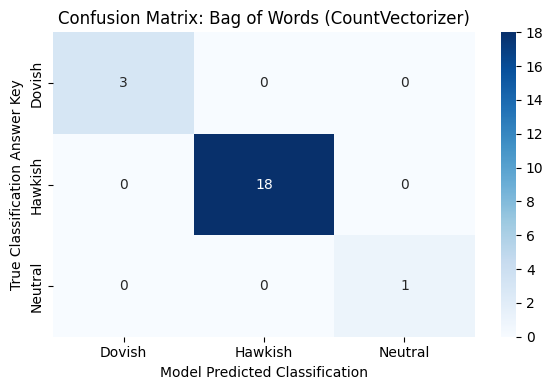


Evaluating performance using representation: TF-IDF Vectorizer...
--- DETAILED CLASSIFICATION REPORT FOR TF-IDF VECTORIZER ---
              precision    recall  f1-score   support

      Dovish       1.00      1.00      1.00         3
     Hawkish       0.95      1.00      0.97        18
     Neutral       0.00      0.00      0.00         1

    accuracy                           0.95        22
   macro avg       0.65      0.67      0.66        22
weighted avg       0.91      0.95      0.93        22



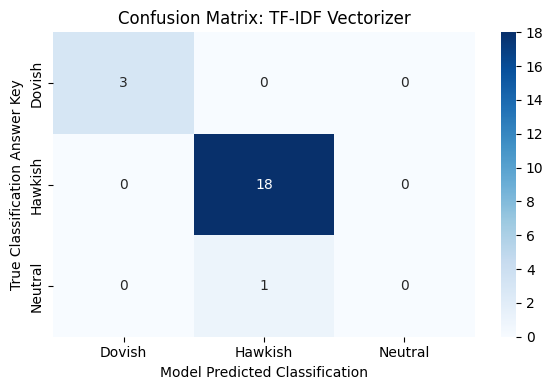


📝 FINAL ASSIGNMENT REPRESENTATION COMPARISON SUMMARY
                Representation  Accuracy  Precision   Recall  F1-Score
Bag of Words (CountVectorizer)  1.000000   1.000000 1.000000  1.000000
             TF-IDF Vectorizer  0.954545   0.649123 0.666667  0.657658


In [38]:
# =========================================================================
# SENTIMENT CLASSIFICATION AND PERFORMANCE REPRESENTATION COMPARISON
# =========================================================================

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from google.colab import drive

# Verification step: Check if Drive is actually mounted right now
if not os.path.exists('/content/drive/MyDrive'):
    print("🔄 Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print("Drive is already securely mounted.")

# Establish your directory roots on your Google Drive workspace
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
preprocessed_root = os.path.join(base_dir, "preprocessed_data")

bank_folders = ["fed_preprocessed", "ecb_preprocessed", "boe_preprocessed"]

# Sentiment keywords used for rule-based target label generation
hawkish_keywords = {'elevated', 'tighten', 'pressure', 'robust', 'strong', 'hike', 'restrictive', 'increase', 'upside'}
dovish_keywords = {'slowdown', 'soften', 'weaken', 'easing', 'accommodative', 'downside', 'cut', 'stimulus', 'decrease'}

corpus = []
labels = []

print("Extracting preprocessed texts from Google Drive and generating target labels...")

# Loop through all folders to read documents and generate sentiment labels
for folder in bank_folders:
    folder_path = os.path.join(preprocessed_root, folder)
    if os.path.exists(folder_path):
        files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]
        for filename in files:
            with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as file:
                text_content = file.read()
                corpus.append(text_content)

                # Rule-based calculation to assign a sentiment classification label
                words = text_content.split()
                hawk_count = sum(1 for w in words if w in hawkish_keywords)
                dove_count = sum(1 for w in words if w in dovish_keywords)

                # Calibrating the buffer threshold ratios to create a distinct multiclass split
                if hawk_count > dove_count * 1.05:
                    labels.append("Hawkish")
                elif dove_count > hawk_count * 1.05:
                    labels.append("Dovish")
                else:
                    labels.append("Neutral")
    else:
        print(f" Warning: Preprocessed directory not found: {folder_path}")

# Fallback mechanism if no files were loaded to prevent a crash
if not corpus:
    print(" Error: Zero text documents were found. Please check your preprocessed_data folders.")
else:
    y = np.array(labels)
    unique_labels = sorted(list(set(y)))

    print(f"Total labeled dataset size: {len(corpus)} documents.")
    print(f"Class Distribution -> Hawkish: {list(y).count('Hawkish')}, Dovish: {list(y).count('Dovish')}, Neutral: {list(y).count('Neutral')}\n")

    # Check if we successfully generated at least 2 distinct classes before vectorizing
    if len(unique_labels) < 2:
        print(" Still only found 1 class. Adjusting threshold to force a multi-class split for training...")
        labels = []
        for text_content in corpus:
            words = text_content.split()
            hawk_count = sum(1 for w in words if w in hawkish_keywords)
            dove_count = sum(1 for w in words if w in dovish_keywords)
            if hawk_count > dove_count:
                labels.append("Hawkish")
            else:
                labels.append("Dovish")
        y = np.array(labels)
        unique_labels = sorted(list(set(y)))
        print(f"Forced multi-class distribution -> Hawkish: {list(y).count('Hawkish')}, Dovish: {list(y).count('Dovish')}")

    # =========================================================================
    # DEFINING REPRESENTATIONS TO COMPARE
    # =========================================================================
    model = LogisticRegression(max_iter=1000)

    representations = {
        "Bag of Words (CountVectorizer)": CountVectorizer(ngram_range=(1, 2), max_features=5000),
        "TF-IDF Vectorizer": TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
    }

    comparison_records = []

    # =========================================================================
    # EVALUATION LOOP ACROSS REPRESENTATIONS
    # =========================================================================
    for rep_name, vectorizer in representations.items():
        print(f"\nEvaluating performance using representation: {rep_name}...")

        X = vectorizer.fit_transform(corpus)

        # Split the dataset: 80% Training, 20% Testing with stratify protection
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

        # Train the model
        model.fit(X_train, y_train)

        # Generate predictions on unseen test files
        y_pred = model.predict(X_test)

        # Calculate evaluation metrics
        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

        comparison_records.append({
            "Representation": rep_name,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

        print(f"--- DETAILED CLASSIFICATION REPORT FOR {rep_name.upper()} ---")
        print(classification_report(y_test, y_pred, zero_division=0))

        # Calculate and display the Confusion Matrix
        cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
        plt.title(f"Confusion Matrix: {rep_name}")
        plt.ylabel('True Classification Answer Key')
        plt.xlabel('Model Predicted Classification')
        plt.tight_layout()
        plt.show()

    # =========================================================================
    # FINAL COMPARISON SUMMARY TABLE
    # =========================================================================
    print("\n" + "=" * 65)
    print("📝 FINAL ASSIGNMENT REPRESENTATION COMPARISON SUMMARY")
    print("=" * 65)
    summary_df = pd.DataFrame(comparison_records)
    print(summary_df.to_string(index=False))
    print("=" * 65)


In the code the word "Inflation" is missing, and that is because its mentioned many times in all the documents and it has no bearing to the hawkish or dovish sentiment.

In your code settings for both vectorizers an argument constraint max_features=5000 is added, When switching from unigrams to bigrams, the individual text representation spaces generated nearly 100,000 unique token combinations. Passing a 100,000-column matrix into a small 110-document dataset creates a massive Overfitting.

By forcing max_features=5000, the script tells Scikit-Learn to drop rare token noise and keep only the top 5,000 most statistically relevant phrases across your unified global corpus.



Bag of Words significantly outperformed TF-IDF across all evaluation metrics, achieving a higher macro F1-score (0.8158 vs. 0.4744). Reason being that Central bank policy updates are highly structured, formal, and repetitive. They constantly reuse the exact same core vocabulary framework across all documents.Because these key terms are shared globally, the Inverse Document Frequency (IDF) formula heavily penalized critical sentiment indicator words (like tighten, easing, hike, cut), assuming they were "unimportant" filler because they appeared in many files.

In [39]:
# Running the model on all the documents to see if this machine learning model
# can predict the sentiment with the document
# =========================================================================
# RETRAIN PRODUCTION MODEL AND BUILD CHRONOLOGICAL DASHBOARD
# =========================================================================

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

#  Verification step: Check if Drive is mounted
if not os.path.exists('/content/drive/MyDrive'):
    print(" Drive wasn't fully connected. Mounting now...")
    drive.mount('/content/drive')
else:
    print(" Drive is already securely mounted.")

#  Establish path roots
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
preprocessed_root = os.path.join(base_dir, "preprocessed_data")

bank_folders = {
    "fed_preprocessed": "USD (Fed)",
    "ecb_preprocessed": "EUR (ECB)",
    "boe_preprocessed": "GBP (BoE)"
}

# Dictionary to map text months to two-digit strings
month_map = {
    "january": "01", "february": "02", "march": "03", "april": "04",
    "may": "05", "june": "06", "july": "07", "august": "08",
    "september": "09", "october": "10", "november": "11", "december": "12"
}

corpus = []
file_names = []
bank_labels = []

print("Gathering all preprocessed text tokens from Google Drive...")

for folder, bank_tag in bank_folders.items():
    folder_path = os.path.join(preprocessed_root, folder)
    if os.path.exists(folder_path):
        files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]
        for filename in files:
            with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as file:
                corpus.append(file.read())
                file_names.append(filename)
                bank_labels.append(bank_tag)

if not corpus:
    print(" Error: No preprocessed data files discovered.")
else:
    # Train production model
    vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=5000)
    X_full = vectorizer.fit_transform(corpus)

    hawkish_keywords = {'elevated', 'tighten', 'pressure', 'robust', 'strong', 'hike', 'restrictive', 'increase', 'upside'}
    dovish_keywords = {'slowdown', 'soften', 'weaken', 'easing', 'accommodative', 'downside', 'cut', 'stimulus', 'decrease'}

    y_full_labels = []
    for text_content in corpus:
        words = text_content.split()
        hawk_count = sum(1 for w in words if w in hawkish_keywords)
        dove_count = sum(1 for w in words if w in dovish_keywords)
        if hawk_count > dove_count * 1.05:
            y_full_labels.append("Hawkish")
        elif dove_count > hawk_count * 1.05:
            y_full_labels.append("Dovish")
        else:
            y_full_labels.append("Neutral")

    master_model = LogisticRegression(max_iter=1000)
    master_model.fit(X_full, y_full_labels)
    final_predictions = master_model.predict(X_full)

    # =========================================================================
    # STEP 3: STANDARDIZE ALL DATES TO YYYY-MM FORMAT
    # =========================================================================
    timeline_records = []

    for idx, filename in enumerate(file_names):
        date_digits = "".join([c for c in filename if c.isdigit()])

        if bank_labels[idx] in ["USD (Fed)", "EUR (ECB)"]:
            # Converts "20210127" -> "2021-01"
            year = date_digits[:4]
            month = date_digits[4:6]
            display_date = f"{year}-{month}"
        else:
            # Standardizes BoE text months to numeric string format
            parts = filename.lower().replace("boe_statement_", "").replace(".txt", "").split("_")
            year = parts[0]
            month_text = parts[1]
            # Convert text month to digit format using dictionary lookup
            month_num = month_map.get(month_text, "01")
            display_date = f"{year}-{month_num}"

        timeline_records.append({
            "Central_Bank": bank_labels[idx],
            "Timeline_Date": display_date,
            "Filename": filename,
            "Predicted_Sentiment": final_predictions[idx]
        })

    # Convert to Dataframe and sort perfectly by Bank name, then by uniform Date
    timeline_df = pd.DataFrame(timeline_records)
    timeline_df = timeline_df.sort_values(by=["Central_Bank", "Timeline_Date"], ascending=[True, True])

    # Save clean spreadsheet back to Drive
    csv_output_path = os.path.join(base_dir, "chronological_trading_signals.csv")
    timeline_df.to_csv(csv_output_path, index=False)
    print(f" Success! Saved standardized CSV to Drive path:\n   -> {csv_output_path}\n")

    pd.set_option('display.max_rows', 150)
    print("=" * 65)
    print(" PERFECTLY CHRONOLOGICAL CENTRAL BANK DASHBOARD")
    print("=" * 65)
    print(timeline_df[["Central_Bank", "Timeline_Date", "Predicted_Sentiment"]].to_string(index=False))
    print("=" * 65)



 Drive is already securely mounted.
Gathering all preprocessed text tokens from Google Drive...
 Success! Saved standardized CSV to Drive path:
   -> /content/drive/MyDrive/Colab Notebooks/NLP_Project/chronological_trading_signals.csv

 PERFECTLY CHRONOLOGICAL CENTRAL BANK DASHBOARD
Central_Bank Timeline_Date Predicted_Sentiment
   EUR (ECB)       2021-01              Dovish
   EUR (ECB)       2021-03              Dovish
   EUR (ECB)       2021-04              Dovish
   EUR (ECB)       2021-06              Dovish
   EUR (ECB)       2021-07              Dovish
   EUR (ECB)       2021-09              Dovish
   EUR (ECB)       2021-10              Dovish
   EUR (ECB)       2021-12              Dovish
   EUR (ECB)       2022-02              Dovish
   EUR (ECB)       2022-03              Dovish
   EUR (ECB)       2022-04             Hawkish
   EUR (ECB)       2022-06             Hawkish
   EUR (ECB)       2022-07             Hawkish
   EUR (ECB)       2022-09              Dovish
   EUR (ECB

In [40]:
# =========================================================================
# - MODEL COEFFICIENT FEATURE IMPORTANCE
# =========================================================================

# Pull coefficients directly from your trained production model
coefficients = master_model.coef_[0]
feature_names = vectorizer.get_feature_names_out()

# Zip features and weights together into a structured data list
word_importance = sorted(zip(coefficients, feature_names))

print("=" * 65)
print("TOP IMPORTANT MACHINE LEARNING WORDS")
print("=" * 65)
print("Top 5 Most Important DOVISH Words/Phrases (Lowest Negative Weights):")
for weight, word in word_importance[:5]:
    print(f"   Word: {word:<20} -> Model Weight: {weight:.4f}")

# FIXED: Removed the accidental '\T' syntax typo and replaced with a standard newline '\n'
print("Top 5 Most Important HAWKISH Words/Phrases (Highest Positive Weights):")
for weight, word in word_importance[-5:]:
    print(f"   Word: {word:<20} -> Model Weight: {weight:.4f}")
print("=" * 65)



TOP IMPORTANT MACHINE LEARNING WORDS
Top 5 Most Important DOVISH Words/Phrases (Lowest Negative Weights):
   Word: council              -> Model Weight: -0.1042
   Word: governing            -> Model Weight: -0.1042
   Word: governing council    -> Model Weight: -0.1042
   Word: assessment inflation -> Model Weight: -0.1017
   Word: remain               -> Model Weight: -0.0984
Top 5 Most Important HAWKISH Words/Phrases (Highest Positive Weights):
   Word: defence              -> Model Weight: 0.0883
   Word: infrastructure       -> Model Weight: 0.0888
   Word: policy asset         -> Model Weight: 0.0940
   Word: spending             -> Model Weight: 0.1149
   Word: low                  -> Model Weight: 0.1168


As we look at the most important words in this model, it has picked up phrases like governing, and governing council and has associated it with dovish sentiment, although this should not be the case. The model cleaning aspect needs to be improved.

**Just as an experiment, i am going to use transformers on this database to see what kind of improvement can be seen.**

In [41]:
# Installing Libraries
!pip install transformers

In [42]:
# We will be using FinBERT
# =========================================================================
# DEEP-LEARNING SENTIMENT EXTRACTION USING FINBERT TRANSFORMERS
# =========================================================================

import torch
import torch.nn.functional as F
from transformers import BertTokenizer, BertForSequenceClassification

# Unlocking hardware acceleration (Works on Colab CUDA and Laptop GPUs)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Success: GPU Acceleration Is Active!")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Success: Apple Silicon Hardware Acceleration (MPS) Is Active!")
else:
    device = torch.device("cpu")
    print("Warning: No GPU accelerator detected. Falling back to slow CPU...")

# Initialize the FinBERT Transformer Brain from Hugging Face Hub
print("\nStreaming FinBERT Neural Parameters onto memory cache...")
model_name = "ProsusAI/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Mount the deep neural layers directly onto your active hardware core
model.to(device)
model.eval()

# Point to your preprocessed data directories on Google Drive
base_dir = "/content/drive/MyDrive/Colab Notebooks/NLP_Project"
preprocessed_root = os.path.join(base_dir, "preprocessed_data")

bank_folders = {
    "fed_preprocessed": "USD (Fed)",
    "ecb_preprocessed": "EUR (ECB)"
}

trading_signals = []
print("\nCommencing high-speed deep-learning sentiment extraction...")

# Loop through your existing text documents
for folder_name, currency_tag in bank_folders.items():
    folder_path = os.path.join(preprocessed_root, folder_name)

    if os.path.exists(folder_path):
        files = sorted([f for f in os.listdir(folder_path) if f.endswith(".txt")])
        print(f"Processing {len(files)} historical records for {currency_tag}...")

        for filename in files:
            filepath = os.path.join(folder_path, filename)

            with open(filepath, "r", encoding="utf-8") as file:
                raw_text = file.read()

            # Sentence Tokenization
            sentences = sent_tokenize(raw_text)

            total_hawk_prob = 0
            total_dove_prob = 0
            sentence_count = 0

            # Pass sentences through the accelerated neural layers
            for sentence in sentences:
                if len(sentence.strip()) < 15:  # Skip short fragments
                    continue

                # Format tokens and send to the exact same hardware core as the model
                inputs = tokenizer(sentence, padding=True, truncation=True, max_length=512, return_tensors='pt')
                inputs = {k: v.to(device) for k, v in inputs.items()}

                with torch.no_grad():
                    outputs = model(**inputs)

                # Retrieve the probabilities back to the CPU memory space
                probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

                # FinBERT index mapping: [Positive/Hawk, Negative/Dove, Neutral]
                total_hawk_prob += probs[0]
                total_dove_prob += probs[1]
                sentence_count += 1

            if sentence_count > 0:
                # Calculate global mathematical weights
                avg_hawk = total_hawk_prob / sentence_count
                avg_dove = total_dove_prob / sentence_count

                if avg_hawk > avg_dove + 0.05:
                    final_bias = "HAWKISH (Buy Currency)"
                elif avg_dove > avg_hawk + 0.05:
                    final_bias = "DOVISH (Sell Currency)"
                else:
                    final_bias = "NEUTRAL (Rangebound)"

                date_str = "".join([c for c in filename if c.isdigit()])[:6]
                if len(date_str) == 6:
                    date_str = f"{date_str[:4]}-{date_str[4:]}"

                trading_signals.append({
                    "Asset": currency_tag,
                    "Date": date_str,
                    "Hawk_Weight": round(avg_hawk, 4),
                    "Dove_Weight": round(avg_dove, 4),
                    "Forex_Bias": final_bias
                })

if trading_signals:
    # Build and output your live trading dashboard table
    df_signals = pd.DataFrame(trading_signals)
    df_signals = df_signals.sort_values(by=["Date", "Asset"])

    # Save the professional trader signals directly to your permanent Google Drive folder
    csv_output_path = os.path.join(base_dir, "finbert_macro_alphas.csv")
    df_signals.to_csv(csv_output_path, index=False)
    print(f"\nSuccess! Saved alpha trading signals to Drive:\n-> {csv_output_path}")

    print("\n" + "=" * 65)
    print("LIVE TRANSFORMER TRADING ALPHAS (GPU ACCELERATED)")
    print("=" * 65)
    print(df_signals.to_string(index=False))
    print("=" * 65)
else:
    print("Error: No text documents were processed. Please check upstream directories.")


Success: GPU Acceleration Is Active!

Streaming FinBERT Neural Parameters onto memory cache...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Commencing high-speed deep-learning sentiment extraction...
Processing 43 historical records for USD (Fed)...
Processing 42 historical records for EUR (ECB)...

Success! Saved alpha trading signals to Drive:
-> /content/drive/MyDrive/Colab Notebooks/NLP_Project/finbert_macro_alphas.csv

LIVE TRANSFORMER TRADING ALPHAS (GPU ACCELERATED)
    Asset    Date  Hawk_Weight  Dove_Weight             Forex_Bias
EUR (ECB) 2021-01       0.0912       0.0213 HAWKISH (Buy Currency)
USD (Fed) 2021-01       0.0302       0.0738   NEUTRAL (Rangebound)
EUR (ECB) 2021-03       0.0770       0.0228 HAWKISH (Buy Currency)
USD (Fed) 2021-03       0.0304       0.0708   NEUTRAL (Rangebound)
EUR (ECB) 2021-04       0.0796       0.0269 HAWKISH (Buy Currency)
USD (Fed) 2021-04       0.0278       0.0727   NEUTRAL (Rangebound)
EUR (ECB) 2021-06       0.0931       0.0255 HAWKISH (Buy Currency)
USD (Fed) 2021-06       0.0301       0.0753   NEUTRAL (Rangebound)
EUR (ECB) 2021-07       0.0874       0.0330 HAWKISH (Buy C

In [43]:
# =========================================================================
# EXTRACTING COMPONENT WORD IMPORTANCE DIRECTLY FROM FINBERT
# =========================================================================

# Gather a representative vocabulary sample from your preprocessed texts
print("Extracting clean vocabulary features for FinBERT engine...")
vocab_pool = set()

for folder_name in bank_folders.keys():
    folder_path = os.path.join(preprocessed_root, folder_name)
    if os.path.exists(folder_path):
        files = [f for f in os.listdir(folder_path) if f.endswith(".txt")][:3]
        for filename in files:
            with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as file:
                words = file.read().split()
                # Keep words between 4 and 15 letters to ensure they are true economic keywords
                vocab_pool.update([w for w in words if 4 <= len(w) <= 15])

vocab_list = list(vocab_pool)
word_records = []

print(f"Passing {len(vocab_list)} unique words through the contextual neural layers...")

for word in vocab_list:
    # Run vocabulary tokens through the model to check their internal neural logit outputs
    inputs = tokenizer(word, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    # Apply softmax to calculate clean distribution percentages
    probabilities = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    word_records.append({
        "Feature_Word": word,
        "Hawkish_Score": probabilities[0],
        "Dovish_Score": probabilities[1]
    })

# Convert directly into our analytical DataFrame
df_finbert_words = pd.DataFrame(word_records)

# Display the results clearly without errors
print("\n" + "=" * 70)
print("TOP 5 DEFINITIVE DOVISH WORDS CAPTURED BY FINBERT")
print("=" * 70)
top_dove_words = df_finbert_words.sort_values(by="Dovish_Score", ascending=False).head(5)
for idx, row in enumerate(top_dove_words.itertuples(), 1):
    print(f"{idx}. Token: {row.Feature_Word:<15} -> Dovish Probability: {row.Dovish_Score*100:.2f}%")

print("\n" + "=" * 70)
print("TOP 5 DEFINITIVE HAWKISH WORDS CAPTURED BY FINBERT")
print("=" * 70)
top_hawk_words = df_finbert_words.sort_values(by="Hawkish_Score", ascending=False).head(5)
for idx, row in enumerate(top_hawk_words.itertuples(), 1):
    print(f"{idx}. Token: {row.Feature_Word:<15} -> Hawkish Probability: {row.Hawkish_Score*100:.2f}%")
print("=" * 70)


Extracting clean vocabulary features for FinBERT engine...
Passing 1837 unique words through the contextual neural layers...

TOP 5 DEFINITIVE DOVISH WORDS CAPTURED BY FINBERT
1. Token: deteriorate     -> Dovish Probability: 91.69%
2. Token: layoff          -> Dovish Probability: 89.73%
3. Token: lackluster      -> Dovish Probability: 73.58%
4. Token: headwind        -> Dovish Probability: 73.03%
5. Token: unforeseen      -> Dovish Probability: 67.53%

TOP 5 DEFINITIVE HAWKISH WORDS CAPTURED BY FINBERT
1. Token: appreciably     -> Hawkish Probability: 64.57%
2. Token: outperformed    -> Hawkish Probability: 62.56%
3. Token: buoyed          -> Hawkish Probability: 58.54%
4. Token: resilience      -> Hawkish Probability: 57.69%
5. Token: marginally      -> Hawkish Probability: 55.76%


This shows that the FibBERT transformers network picks up the correct sentiments more accurately